In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Carregar dataset
df_receita = pd.read_csv('./datasets/dataset_receita.csv')

In [3]:
# Inspecionar estrutura do dataframe
df_receita.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tempo_de_experiencia  100 non-null    int64  
 1   numero_de_vendas      100 non-null    int64  
 2   fator_sazonal         100 non-null    int64  
 3   receita_em_reais      100 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


In [ ]:
# Copiar DF para DF EDA
df_receita_eda = df_receita.copy()

In [ ]:
# Copiar DF para DF Bucketing
df_receita_bucketing = df_receita.copy()

### EDA

In [6]:
# Visualizar os dados
df_receita_eda.head(10)

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais
0,36,21,5,2639.886941
1,74,44,10,4707.322227
2,38,44,4,5910.035131
3,52,62,6,6130.742546
4,97,56,2,7516.457681
5,67,70,10,1247.882324
6,119,69,2,3485.606208
7,66,62,2,2773.987427
8,68,96,3,4177.919578
9,106,42,2,4719.691069


In [7]:
# Detectar valores ausentes
df_receita_eda.isna().sum()

tempo_de_experiencia    0
numero_de_vendas        0
fator_sazonal           0
receita_em_reais        0
dtype: int64

In [8]:
# Medidas Estatisticas
df_receita_eda.describe()

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais
count,100.000000,100.000000,100.000000,100.000000
mean,64.490000,54.490000,5.820000,5112.941924
std,32.397935,25.307201,2.836914,2544.731052
min,1.000000,10.000000,1.000000,1133.363948
25%,38.750000,37.500000,4.000000,2800.660516
50%,64.500000,52.500000,5.000000,4953.770034
75%,93.000000,70.500000,8.000000,7079.500163
max,119.000000,100.000000,10.000000,9941.016458


<Axes: xlabel='tempo_de_experiencia'>

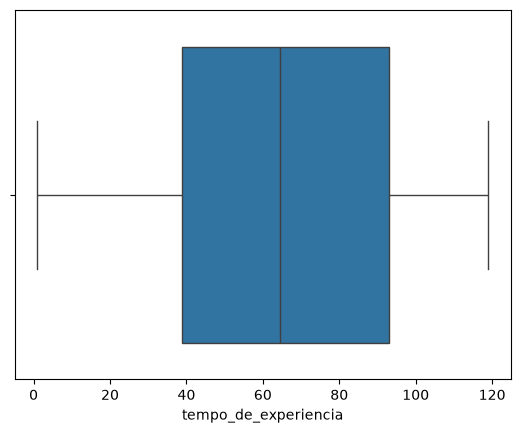

In [9]:
# Verificar / detectar outliers
sns.boxplot(data=df_receita_eda, x='tempo_de_experiencia')

<Axes: xlabel='numero_de_vendas'>

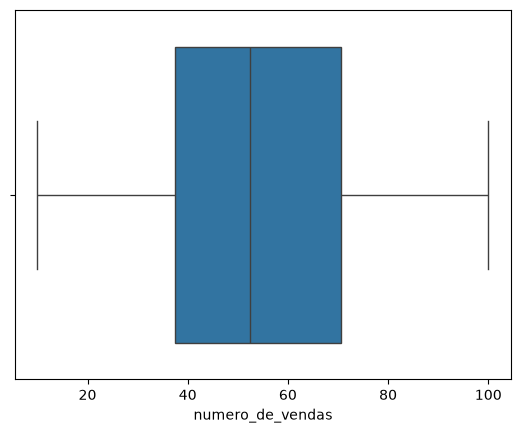

In [10]:
# Verificar / detectar outliers
sns.boxplot(data=df_receita_eda, x='numero_de_vendas')

<Axes: xlabel='fator_sazonal'>

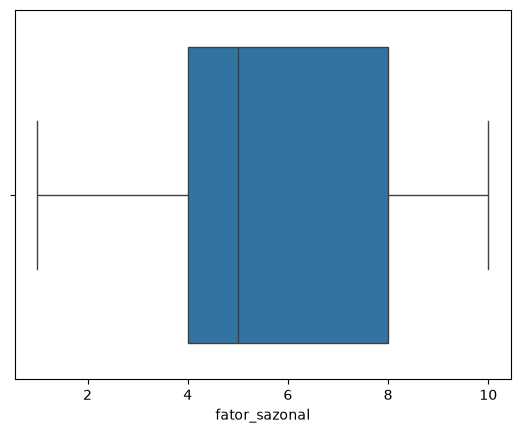

In [11]:
# Verificar / detectar outliers
sns.boxplot(data=df_receita_eda, x='fator_sazonal')

<Axes: xlabel='receita_em_reais'>

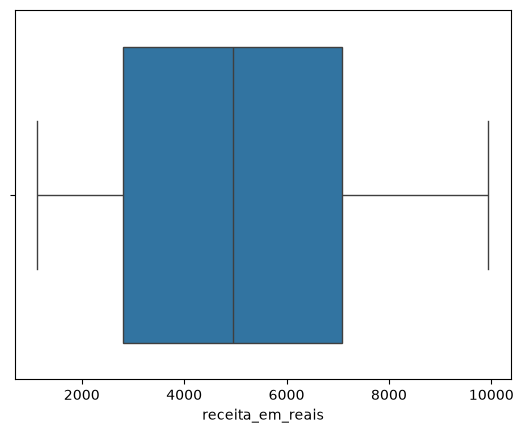

In [12]:
# Verificar / detectar outliers
sns.boxplot(data=df_receita_eda, x='receita_em_reais')

<Axes: xlabel='tempo_de_experiencia', ylabel='receita_em_reais'>

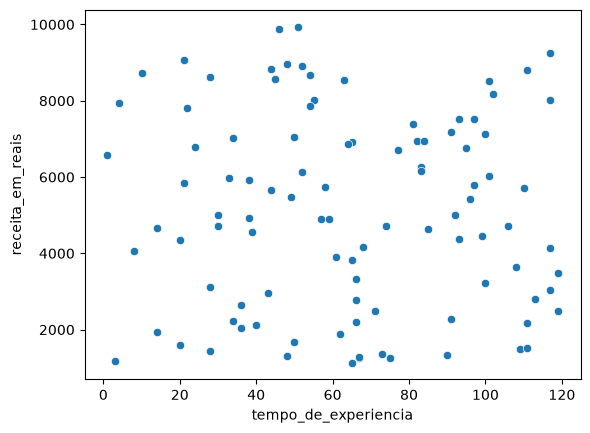

In [13]:
# Cruzamente variaveis numericas com receita em reais (variavel dependente)
sns.scatterplot(data=df_receita_eda, x='tempo_de_experiencia', y='receita_em_reais')

<Axes: xlabel='numero_de_vendas', ylabel='receita_em_reais'>

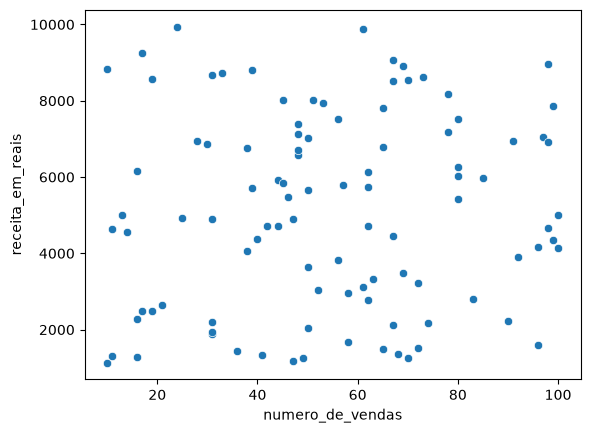

In [14]:
sns.scatterplot(data=df_receita_eda, x='numero_de_vendas', y='receita_em_reais')

<Axes: xlabel='fator_sazonal', ylabel='receita_em_reais'>

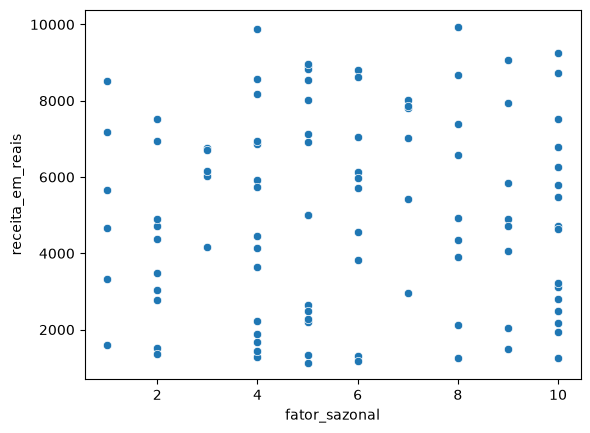

In [15]:
sns.scatterplot(data=df_receita_eda, x='fator_sazonal', y='receita_em_reais')

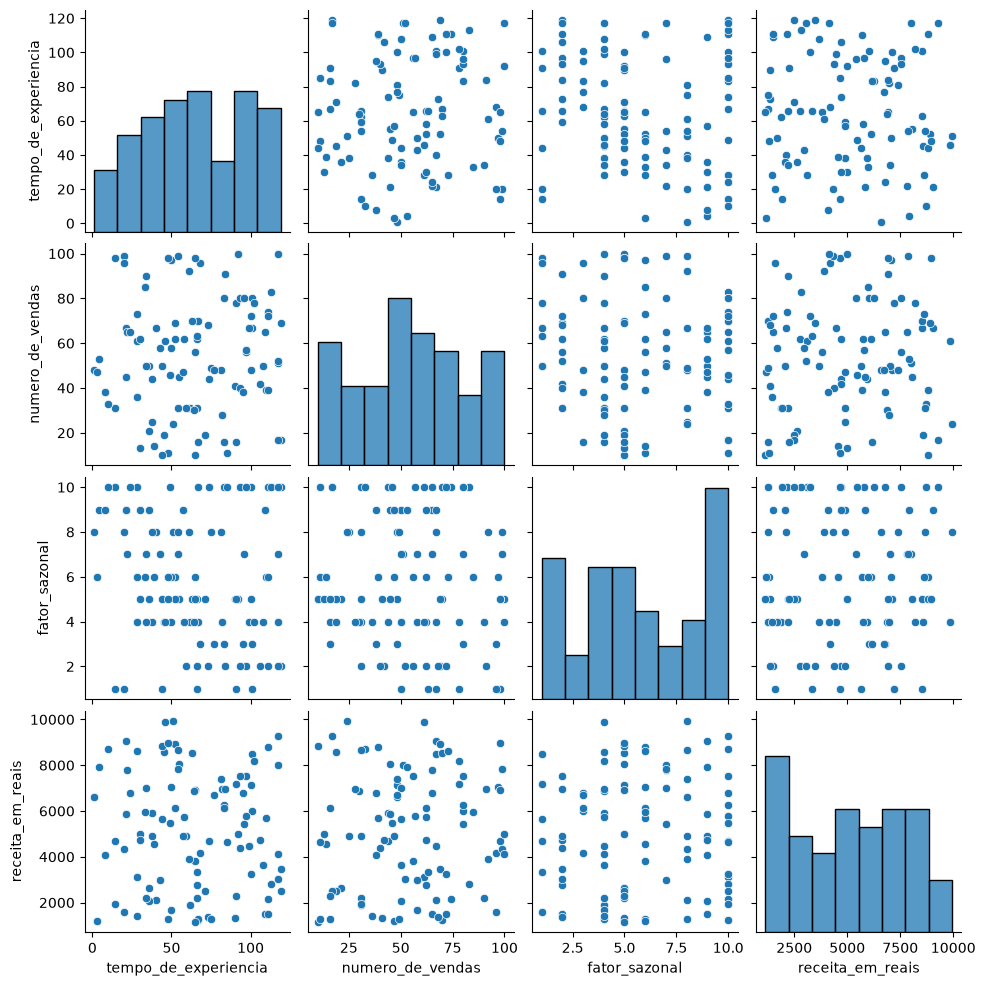

In [16]:
# Histograma das váriaveis
sns.pairplot(df_receita_eda)

<Axes: >

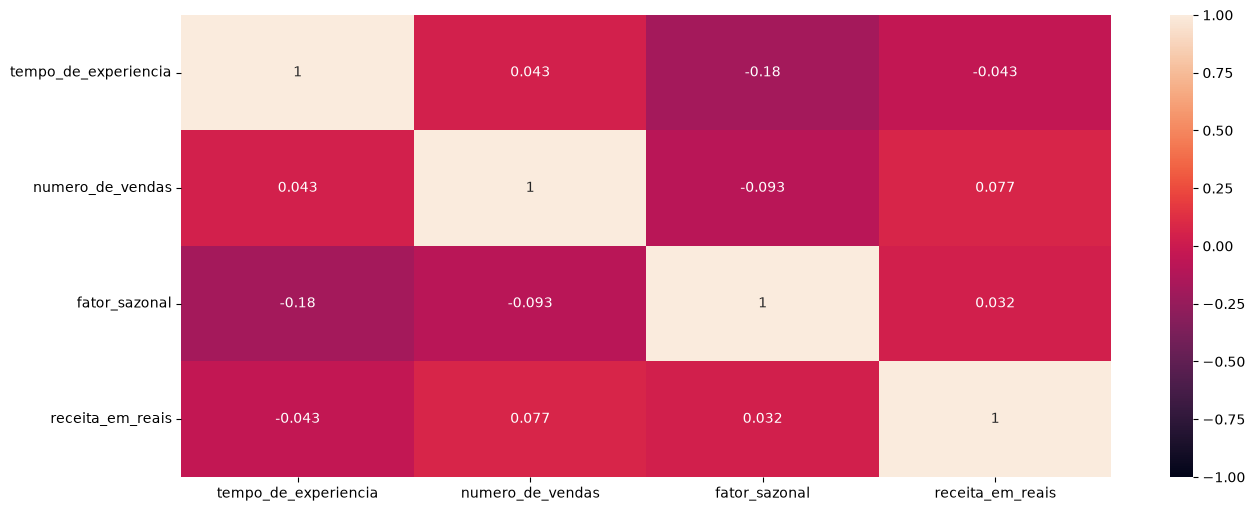

In [17]:
# mapa de calor
plt.figure(figsize=(15,6))
sns.heatmap(df_receita_eda.corr(), vmin=-1, vmax=1, annot=True)

<Axes: >

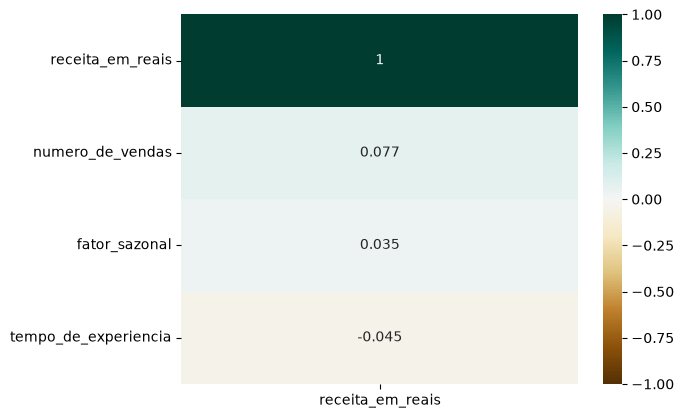

In [18]:
# Formato em Ranking
sns.heatmap(df_receita_eda.corr('spearman')[['receita_em_reais']].sort_values(
  by='receita_em_reais', ascending=False
), vmin=-1, vmax=1, annot=True, cmap='BrBG')

In [19]:
# Bucketing Tempo Experiencia
bins_tempo_experiencia = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
labels_tempo_experiencia = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99', '100-109', '110-119']
df_receita_bucketing['escala_tempo'] = pd.cut(x=df_receita_bucketing['tempo_de_experiencia'], bins=bins_tempo_experiencia, labels=labels_tempo_experiencia, include_lowest=True)

In [20]:
df_receita_bucketing.head(10)

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais,escala_tempo
0,36,21,5,2639.886941,30-39
1,74,44,10,4707.322227,70-79
2,38,44,4,5910.035131,30-39
3,52,62,6,6130.742546,50-59
4,97,56,2,7516.457681,90-99
5,67,70,10,1247.882324,60-69
6,119,69,2,3485.606208,110-119
7,66,62,2,2773.987427,60-69
8,68,96,3,4177.919578,60-69
9,106,42,2,4719.691069,100-109


<Axes: xlabel='escala_tempo', ylabel='receita_em_reais'>

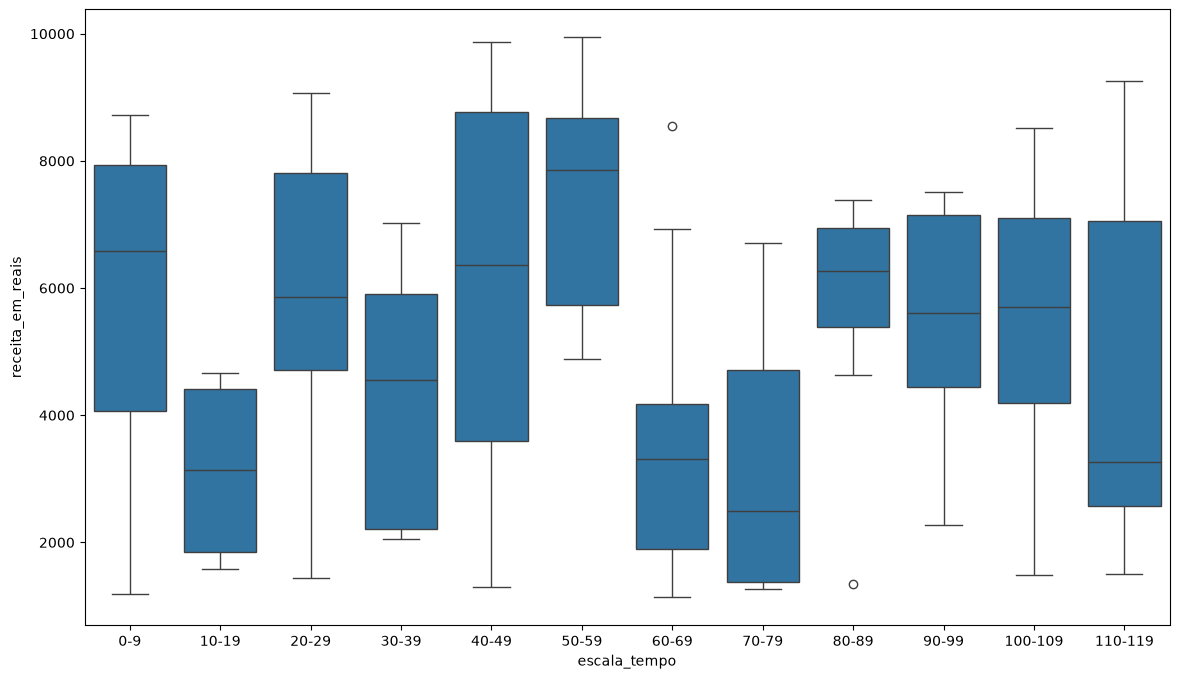

In [21]:
plt.figure(figsize=(14, 8))
sns.boxplot(df_receita_bucketing, x='escala_tempo', y='receita_em_reais')

### Treinar Modelo Linear

In [22]:
# Importar Bibliotecas
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np

In [23]:
X = df_receita.drop(columns=['receita_em_reais', 'fator_sazonal'])
y = df_receita['receita_em_reais']

In [24]:
X.head(10)

,tempo_de_experiencia,numero_de_vendas
0,36,21
1,74,44
2,38,44
3,52,62
4,97,56
5,67,70
6,119,69
7,66,62
8,68,96
9,106,42


In [25]:
# Split usando Kfold com 5 pastas/splits
kf = KFold(n_splits=5, shuffle=True, random_state=51)

In [26]:
kf

KFold(n_splits=5, random_state=51, shuffle=True)

In [27]:
# Bloco para treinamento do modelo

# Pipeline
# Padronizar variaveis numericas - tempo_de_experiencia, numero_de_vendas

# Nomes das Colunas
colunas_numericas = ['tempo_de_experiencia', 'numero_de_vendas']

# Transformar para colunas numéricas
tranformer_numericas = Pipeline(steps=[
  ('scaler', StandardScaler())
])

# Criar um ColumnTransformer
preprocessor = ColumnTransformer(
  transformers=[
    ('num', tranformer_numericas, colunas_numericas)
  ]
)

# Criando Pipeline principal = Pre Processamento + Treinamento
model_regr = Pipeline(steps=[
  ('preprocessor', preprocessor),
  ('regressor', LinearRegression())
])

# Armazenar RMSE Treino e Teste
rmse_scores_fold_train = []
rmse_scores_fold_test = []

# Armzenar R2 Socre de Teste
r2score_fold_test = []

# Armazenar Residuos
residuos = []

# Armazenar Predições
y_pred_total = []

for train_index, test_index in kf.split(X):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  # Treine o modelo no conjunto de treinamento
  model_regr.fit(X_train, y_train)

  # Faça predições nos conjuntos de treinamento e teste
  y_train_pred = model_regr.predict(X_train)
  y_test_pred = model_regr.predict(X_test)

  # Calcule o RMSE para os conjuntos de treinamento e teste
  rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
  rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

  # Calcular R2Score e Residuos para o conjunto de teste
  r2score_test = r2_score(y_test, y_test_pred)
  residuos_test = np.array(y_test-y_test_pred)

  # Armazenar as metricas da iteração na lista
  rmse_scores_fold_train.append(rmse_train)
  rmse_scores_fold_test.append(rmse_test)
  r2score_fold_test.append(r2score_test)
  residuos.append(residuos_test)
  y_pred_total.append(y_test_pred)

rmse_train_final = np.mean(rmse_scores_fold_train)
rmse_test_final = np.mean(rmse_scores_fold_test)
r2score_test_final = np.mean(r2score_fold_test)
percentual_rmse_final = ((rmse_test_final - rmse_train_final) / rmse_train_final) * 100
residuos = np.array(residuos).reshape(-1)
y_pred_total = np.array(y_pred_total).reshape(-1)

### Analise de Métricas - Modelo Linear

In [28]:
# Métricas

print(f'RMSE Treino: {rmse_train_final}')
print(f'RMSE Teste: {rmse_test_final}')
print(f'% Dif. RMSE Treino e Teste: {percentual_rmse_final}')
print(f'R2Score Teste: {r2score_test_final}')

RMSE Treino: 2506.4020236861
RMSE Teste: 2646.215898584393
% Dif. RMSE Treino e Teste: 5.578270108985637
R2Score Teste: -0.13451763390799445


### Analise de Residuos - Modelo Linear

In [29]:
# Transformar residuos na escala padrão
# (X - media) / desvio_padrao

from scipy.stats import zscore
residuos_std = zscore(residuos)

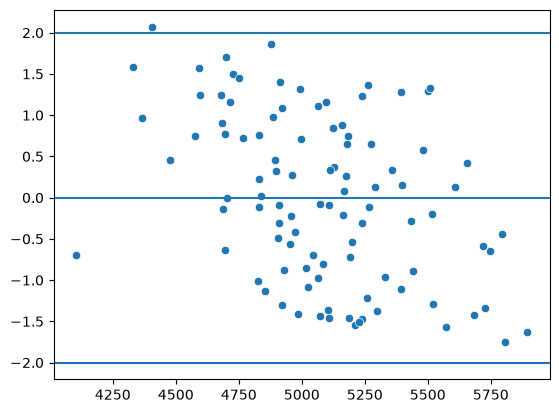

In [31]:
# Verificar linearidade dos residuos: Valores entre -2 e +2 (Escala Padrão)
# Verificar homocedasticidade: Valores em torno da reta sem nenhuma tendencia ou formato
sns.scatterplot(x=y_pred_total, y=residuos_std)
plt.axhline(y=0)
plt.axhline(y=-2)
plt.axhline(y=2)

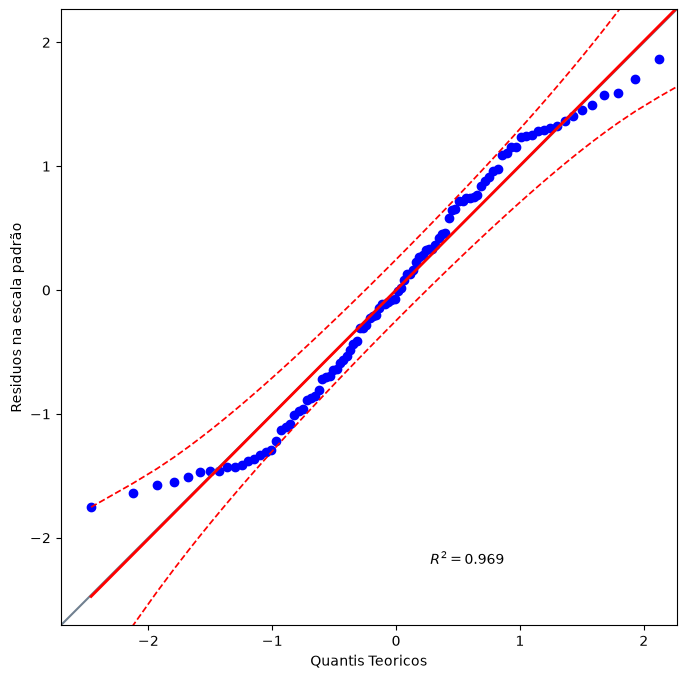

In [32]:
# Checar se residuos seguem uma distribuição normal
## QQ Plot
import pingouin as pg
plt.figure(figsize=(14,8))
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis Teoricos')
plt.ylabel('Residuos na escala padrão')
plt.show()

- Pleo grafico, estão dentro dos limites da escala, idicando seguirem uma distribuição normal

In [33]:
# Teste de Normalidade - Shapiro-Wilk
from scipy.stats import shapiro, kstest
from statsmodels.stats.diagnostic import lilliefors

stat_shapiro, p_value_shapiro = shapiro(residuos)

print (f"Estat. Teste {stat_shapiro} e P-Value {p_value_shapiro}")

Estat. Teste 0.9620260352080697 e P-Value 0.005622713692425516


In [34]:
# Teste de Normaliade - Kolmogorov-Smirnov

stat_ks, p_value_ks = kstest(residuos, 'norm')

print (f"Estat. Teste {stat_ks} e P-Value {p_value_ks}")

Estat. Teste 0.5 e P-Value 1.2131434371817858e-23


In [35]:
# Teste de Normalidade - Lilliefors

stat_ll, p_value_ll = lilliefors(residuos, dist='norm', pvalmethod='table')

print (f"Estat. Teste {stat_ll} e P-Value {p_value_ll}")

Estat. Teste 0.07183455833308328 e P-Value 0.23437942070433532


Todos os p-value deram menor que 0.5, indicando que não seguem uma normalidade.

### Treinar Modelo Polinomial

In [36]:
X = df_receita.drop(columns=['receita_em_reais'])
y = df_receita['receita_em_reais']

In [47]:
X.head(10)

,tempo_de_experiencia,numero_de_vendas,fator_sazonal
0,36,21,5
1,74,44,10
2,38,44,4
3,52,62,6
4,97,56,2
5,67,70,10
6,119,69,2
7,66,62,2
8,68,96,3
9,106,42,2


In [38]:
# Split usando Kfold com 5 pastas/splits
kf = KFold(n_splits=5, shuffle=True, random_state=51)

In [ ]:
# Bloco para Treinamento do Modelo

#graus_polynomial = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
graus_polynomial = [3]

rmse_train_values = []
rmse_test_values = []
percentual_rmse_values = []
r2score_test_values = []

# Split usando Kfold com 5 pastas/splits
kf = KFold(n_splits=5, shuffle=True, random_state=51)

for grau in graus_polynomial:

  # Pipeline
  # Padronizar variaveis numericas - tempo_na_empresa, nivel_na_empresa

  # Nomes das Colunas
  colunas_numericas = ['tempo_de_experiencia', 'numero_de_vendas', 'fator_sazonal']

  # Transformer para Colunas Numéricas
  transformer_numericas = Pipeline(steps=[
    ('scaler', StandardScaler())
  ])

  # Criar um ColumnTransformer
  preprocessor = ColumnTransformer(
    transformers=[
      ('num', transformer_numericas, colunas_numericas)
    ]
  )

  # Criar Features Polinomiais
  poly_feat = PolynomialFeatures(degree=grau, include_bias=False)

  # Criando o Pipeline principal = Pre-Processamento + Treinamento
  model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly_features', poly_feat),
    ('regressor', LinearRegression())
  ])

  # Armazenar RMSE Treino e Teste
  rmse_scores_fold_train = []
  rmse_scores_fold_test = []

  # Armazenar R2 Score de Teste
  r2score_fold_test = []

  # Armazenar Residuos
  residuos = []

  # Armazenar Predições
  y_pred_total = []

  for train_index, test_index in kf.split(X): 
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Treine o modelo no conjunto de treinamento
    model_poly.fit(X_train, y_train)

    # Faça predições nos conjuntos de treinamento e teste
    y_train_pred = model_poly.predict(X_train)
    y_test_pred = model_poly.predict(X_test)

    # Calcule o RMSE para os conjuntos de treinamento e teste
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Calcular R2Score e Residuos para conjunto de teste
    r2score_test = r2_score(y_test, y_test_pred)
    residuos_test = np.array(y_test - y_test_pred)

    #Armazeno as metricas da iteração na lista
    rmse_scores_fold_train.append(rmse_train)
    rmse_scores_fold_test.append(rmse_test)
    r2score_fold_test.append(r2score_test)
    residuos.append(residuos_test)
    y_pred_total.append(y_test_pred)

  rmse_train_final = np.mean(rmse_scores_fold_train)
  rmse_test_final = np.mean(rmse_scores_fold_test)
  r2score_test_final = np.mean(r2score_fold_test)
  percentual_rmse_final = ((rmse_test_final - rmse_train_final) / rmse_train_final) * 100
  residuos = np.array(residuos).reshape(-1)
  y_pred_total = np.array(y_pred_total).reshape(-1)

  rmse_train_values.append(rmse_train_final)
  rmse_test_values.append(rmse_test_final)
  r2score_test_values.append(r2score_test_final)
  percentual_rmse_values.append(percentual_rmse_final)

In [51]:
rmse_train_values

[np.float64(1938.736213972763)]

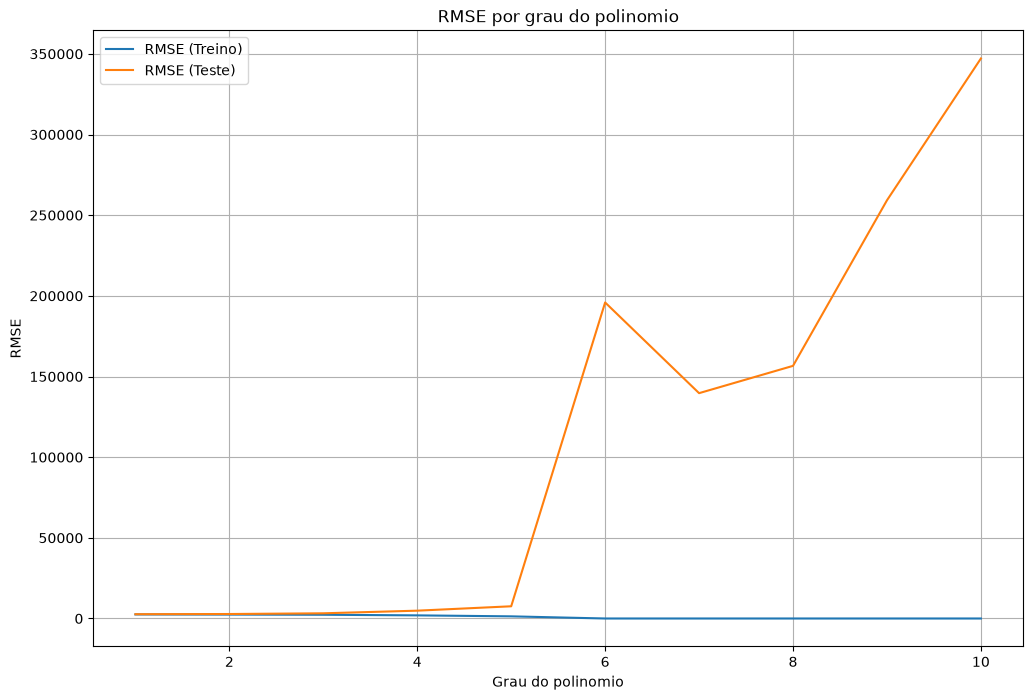

In [56]:
# Plotar G´rafico para comparar RMSE por grau de Polinomio
plt.figure(figsize=(12,8))
plt.plot(graus_polynomial, rmse_train_values, label='RMSE (Treino)')
plt.plot(graus_polynomial, rmse_test_values, label='RMSE (Teste)')
plt.xlabel('Grau do polinomio')
plt.ylabel('RMSE')
plt.title('RMSE por grau do polinomio')
plt.legend()
plt.grid(True)
plt.show()

- Até o grau 3 ele ainda se manteve instabel, no 4 começou a subir um pouco

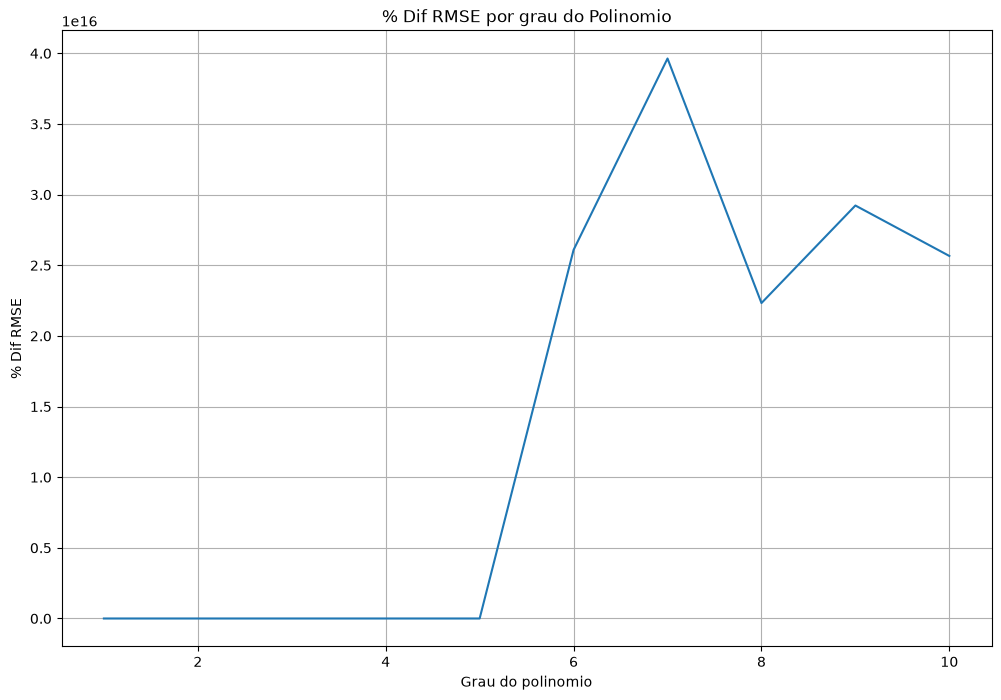

In [57]:
# Plotar Gráfico para comparar %Dif RMSE (Treino e Teste)
plt.figure(figsize=(12,8))
plt.plot(graus_polynomial, percentual_rmse_values, label='% Dif RMSE Treino e Teste')
plt.xlabel('Grau do polinomio')
plt.ylabel('% Dif RMSE')
plt.title('% Dif RMSE por grau do Polinomio')
plt.grid(True)
plt.show()

- Pela porcentagem de erro do RMSE, mostra que até o grau 5 tem uma estabilização, mas apatir do 6, ele aumenta muito a porcentagem do erro, sendo periogos acontecer o Overfiting

- Voltado no treinamento do modelo e executado o treinamento apenas para o grau de polinomio 3

### Analise de Métricas - Modelo Polinomial

In [54]:
# Métricas 
print(f'RMSE Treino: {rmse_train_final}')
print(f'RMSE Teste: {rmse_test_final}')
print(f'% Dif. RMSE Treino e Teste: {percentual_rmse_final}')
print(f'R2Score Teste: {r2score_test_final}')


RMSE Treino: 1938.736213972763
RMSE Teste: 4849.414608289951
% Dif. RMSE Treino e Teste: 150.13277068533054
R2Score Teste: -3.4414132436093645


### Analise de Residuos - Modelo Polinomial

In [60]:
# Transformar residuos na escala padrão
# (X - media) / desvio_padrao

from scipy.stats import zscore
residuos_std = zscore(residuos)

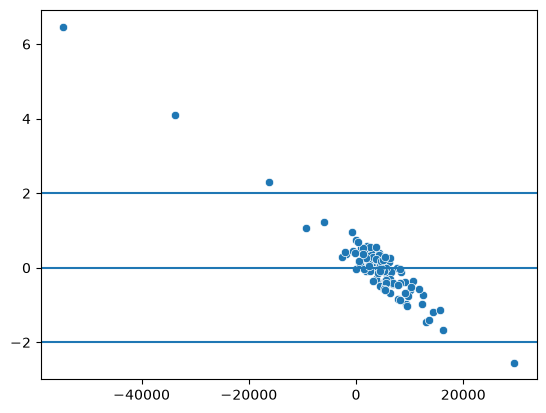

In [61]:
# Verificar linearidade dos residuos: Valores entre -2 e +2 (Escala Padrão)
# Verificar homocedasticidade: Valores em torno da reta sem nenhuma tendência ou formato
sns.scatterplot(x=y_pred_total, y=residuos_std)
plt.axhline(y=0)
plt.axhline(y=-2)
plt.axhline(y=2)

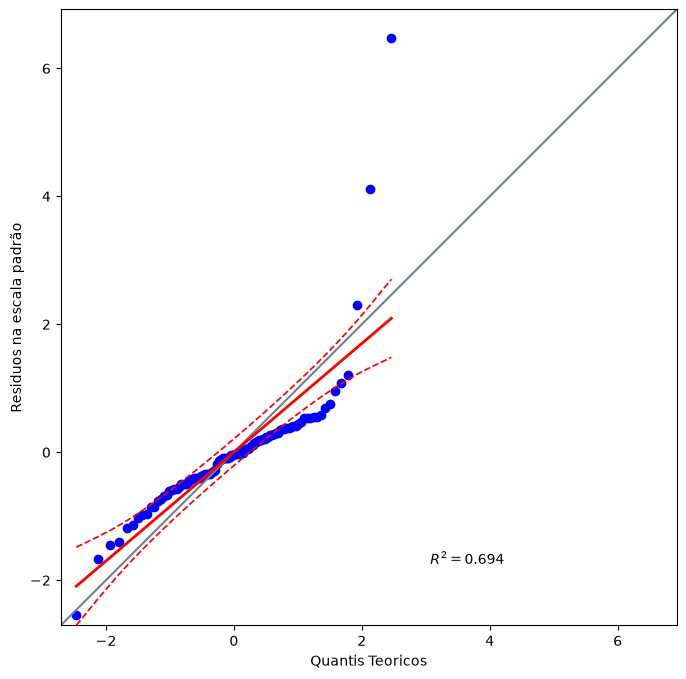

In [62]:
# Checar se residuos seguem uma distribuição normal
# QQ Plot
import pingouin as pg
plt.figure(figsize=(14,8))
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis Teoricos')
plt.ylabel('Residuos na escala padrão')
plt.show()

In [63]:
# Teste de Normalidade - Shapiro-Wilk
from scipy.stats import shapiro, kstest
from statsmodels.stats.diagnostic import lilliefors

stat_shapiro, p_value_shapiro = shapiro(residuos)

print(f"Estat. Teste {stat_shapiro} e P-Value {p_value_shapiro}")

Estat. Teste 0.7156362934030189 e P-Value 1.2675762675951062e-12


In [64]:
# Teste de Normalidade - Kolmogorov-Smirnov

stat_ks, p_value_ks = kstest(residuos, 'norm')

print(f"Estat. Teste {stat_ks} e P-Value {p_value_ks}")

Estat. Teste 0.6 e P-Value 5.912822156396238e-35


In [65]:
# Teste de Normalidade - Lilliefors

stat_ll, p_value_ll = lilliefors(residuos, dist='norm', pvalmethod='table')

print(f"Estat. Teste {stat_ll} e P-Value {p_value_ll}")

Estat. Teste 0.20182996901718275 e P-Value 0.0009999999999998899


- Concluido que o modelo polinomial se concluiu bem pior que o modelo linear, pelo P-Value de shapiro de lilliefors, foram muito menores, além dos valores de RMSE Treino e Final que diferença uma diferença muito grande, de quase 150%